# Final Python Notebook 2 — Classification Modelling & Hyperparameter Tuning

---

**Author Name:** Mathushihan Rathnatheepan

**Student ID:** 20232274/w2120253

**Module Name:** 5DATA002W.2 Machine Learning & Data Mining

**Date:** April 2025

---

**Peer Review Information**

* **Peer Reviewer Name:** Kriththigan Satkunam
* **Date of Review:** 25/03/2026
* **Session:** Code Peer-Review Meeting 2 (Week 8)

**Tests Checked by Peer Reviewer:**
1. All three models (NB, LR, KNN) train and produce predictions without errors
2. The train-test split uses `stratify=y` and `random_state=42` — confirmed same test set across all models
3. GridSearchCV runs on the best model and the optimised hyperparameters are printed correctly

**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Import libraries and load the cleaned classification dataset produced by Notebook 1

In [1]:
# pandas for data handling
import pandas as pd

# numpy for numerical operations
import numpy as np

# matplotlib and seaborn for all visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
# Using Colab/Jupyter inline display so plots appear inside notebook cells
# matplotlib.use('Agg')
%matplotlib inline

# the three classifiers we're building in this notebook
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier

# train-test split and GridSearchCV for hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# StandardScaler normalises features — needed for LR and KNN which are distance/magnitude sensitive
from sklearn.preprocessing import StandardScaler

# all the evaluation metrics we need
from sklearn.metrics import (accuracy_score, recall_score, precision_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay)

# suppress non-critical warnings to keep the output clean
import warnings
warnings.filterwarnings('ignore')

# load Dataset A — the cleaned classification dataset from Notebook 1
df = pd.read_csv('Dataset_A_Classification.csv')

# quick check on shape and first few rows
print('Dataset shape:', df.shape)
df.head()

Dataset shape: (58642, 19)


,age,income,employment_length,loan_amount,loan_interest_rate,loan_income_ratio,payment_default_on_file,credit_history_length,loan_approval_status,home_ownership_MORTGAGE,home_ownership_OTHER,home_ownership_OWN,home_ownership_RENT,loan_intent_DEBTCONSOLIDATION,loan_intent_EDUCATION,loan_intent_HOMEIMPROVEMENT,loan_intent_MEDICAL,loan_intent_PERSONAL,loan_intent_VENTURE
0,40,176400,3,35000,8.00,0.19,0,11,0,0,0,0,1,0,1,0,0,0,0
1,40,90000,3,35000,12.42,0.39,0,14,0,1,0,0,0,0,0,1,0,0,0
2,40,131004,9,30000,7.90,0.23,0,13,0,1,0,0,0,0,0,0,0,0,1
3,40,150000,9,25000,11.89,0.17,0,11,0,1,0,0,0,1,0,0,0,0,0
4,40,132000,3,25000,16.82,0.22,0,17,0,1,0,0,0,0,0,1,0,0,0


**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Define input features and target variable, then perform the train-test split

In [2]:
# separate the input features from the target variable
# X holds all predictor columns; y holds only what we're trying to predict
X = df.drop(columns=['loan_approval_status'])
y = df['loan_approval_status']

# print all feature names and the dataset shape as required by the report
print('Feature names used for classification:')
print(list(X.columns))
print('\nX shape:', X.shape)
print('y shape:', y.shape)

Feature names used for classification:
['age', 'income', 'employment_length', 'loan_amount', 'loan_interest_rate', 'loan_income_ratio', 'payment_default_on_file', 'credit_history_length', 'home_ownership_MORTGAGE', 'home_ownership_OTHER', 'home_ownership_OWN', 'home_ownership_RENT', 'loan_intent_DEBTCONSOLIDATION', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE']

X shape: (58642, 18)
y shape: (58642,)


In [3]:
# split into 80% training and 20% test
# test_size=0.2 gives an 80/20 split — widely recommended for datasets of this size
# random_state=42 makes the split reproducible — every run produces the exact same split
# stratify=y ensures the class ratio (Approved vs Rejected) is preserved in both subsets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# confirm the split sizes
print(f'Training set size: {X_train.shape[0]} rows')
print(f'Test set size:     {X_test.shape[0]} rows')

# confirm the class ratio is the same in both subsets — proof of stratification working
print(f'\nTraining set label distribution:')
print(y_train.value_counts())
print(f'Training class ratio (Rejected %): {y_train.mean():.4f}')

print(f'\nTest set label distribution:')
print(y_test.value_counts())
print(f'Test class ratio (Rejected %):     {y_test.mean():.4f}')

Training set size: 46913 rows
Test set size:     11729 rows

Training set label distribution:
loan_approval_status
0    40233
1     6680
Name: count, dtype: int64
Training class ratio (Rejected %): 0.1424

Test set label distribution:
loan_approval_status
0    10059
1     1670
Name: count, dtype: int64
Test class ratio (Rejected %):     0.1424


In [4]:
# LR and KNN are sensitive to feature scale — a feature with values 0-1,900,000
# would dominate over a feature with values 0-30 if we don't normalise
# StandardScaler transforms each feature to have mean=0 and std=1
# IMPORTANT: fit the scaler only on training data, then apply to test data
# fitting on test data would be a data leakage error
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Scaling applied — training data used to fit the scaler')
print('Test data transformed using training statistics only')

Scaling applied — training data used to fit the scaler
Test data transformed using training statistics only


**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Build and evaluate the Naive Bayes classifier

In [5]:
# create the Gaussian Naive Bayes model
# GaussianNB assumes each feature follows a normal distribution within each class
# NB does not require scaling — it models each feature independently
nb_model = GaussianNB()

# train the model on the unscaled training data
nb_model.fit(X_train, y_train)

# generate predictions on the test set
y_pred_nb = nb_model.predict(X_test)

# get probability scores for the positive class (Rejected=1) — needed for AUC-ROC
y_prob_nb = nb_model.predict_proba(X_test)[:, 1]

print('Naive Bayes model trained and predictions generated')

Naive Bayes model trained and predictions generated


In [6]:
# print the full classification report — shows precision, recall, f1 per class
print('=== Naive Bayes — Classification Report ===')
print(classification_report(y_test, y_pred_nb, target_names=['Approved (0)', 'Rejected (1)']))

# calculate and print all five evaluation metrics
nb_accuracy  = accuracy_score(y_test, y_pred_nb)
nb_recall    = recall_score(y_test, y_pred_nb)
nb_precision = precision_score(y_test, y_pred_nb)
nb_f1        = f1_score(y_test, y_pred_nb)
nb_auc       = roc_auc_score(y_test, y_prob_nb)

print(f'Accuracy:  {nb_accuracy:.4f}')
print(f'Recall:    {nb_recall:.4f}')
print(f'Precision: {nb_precision:.4f}')
print(f'F1-Score:  {nb_f1:.4f}')
print(f'AUC-ROC:   {nb_auc:.4f}')

=== Naive Bayes — Classification Report ===
              precision    recall  f1-score   support

Approved (0)       0.90      0.98      0.94     10059
Rejected (1)       0.72      0.32      0.44      1670

    accuracy                           0.89     11729
   macro avg       0.81      0.65      0.69     11729
weighted avg       0.87      0.89      0.87     11729

Accuracy:  0.8851
Recall:    0.3174
Precision: 0.7182
F1-Score:  0.4402
AUC-ROC:   0.8448


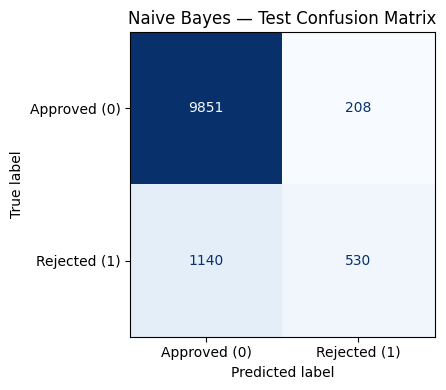

In [7]:
# plot confusion matrix for Naive Bayes
fig, ax = plt.subplots(figsize=(5, 4))
cm_nb = confusion_matrix(y_test, y_pred_nb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_nb,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Naive Bayes — Test Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_nb.png', dpi=150)
plt.show()

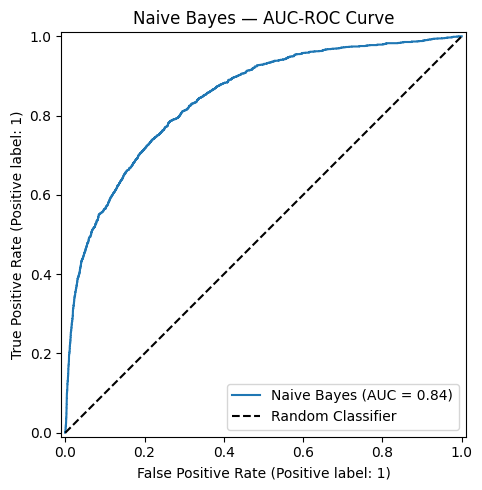

In [8]:
# plot AUC-ROC curve for Naive Bayes
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_nb, ax=ax,
                                  name='Naive Bayes')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('Naive Bayes — AUC-ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_nb.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Build and evaluate the Logistic Regression classifier

In [9]:
# create the Logistic Regression model
# max_iter=1000 gives the solver enough iterations to converge on this dataset
# random_state=42 ensures reproducibility
# LR uses the scaled features because it is sensitive to feature magnitudes
lr_model = LogisticRegression(max_iter=1000, random_state=42)

# train on the scaled training data
lr_model.fit(X_train_sc, y_train)

# generate predictions on the scaled test data
y_pred_lr = lr_model.predict(X_test_sc)

# probability scores for the positive class — needed for AUC-ROC
y_prob_lr = lr_model.predict_proba(X_test_sc)[:, 1]

print('Logistic Regression model trained and predictions generated')

Logistic Regression model trained and predictions generated


In [10]:
# print the full classification report
print('=== Logistic Regression — Classification Report ===')
print(classification_report(y_test, y_pred_lr, target_names=['Approved (0)', 'Rejected (1)']))

# calculate all five metrics
lr_accuracy  = accuracy_score(y_test, y_pred_lr)
lr_recall    = recall_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr)
lr_f1        = f1_score(y_test, y_pred_lr)
lr_auc       = roc_auc_score(y_test, y_prob_lr)

print(f'Accuracy:  {lr_accuracy:.4f}')
print(f'Recall:    {lr_recall:.4f}')
print(f'Precision: {lr_precision:.4f}')
print(f'F1-Score:  {lr_f1:.4f}')
print(f'AUC-ROC:   {lr_auc:.4f}')

=== Logistic Regression — Classification Report ===
              precision    recall  f1-score   support

Approved (0)       0.91      0.97      0.94     10059
Rejected (1)       0.74      0.43      0.54      1670

    accuracy                           0.90     11729
   macro avg       0.82      0.70      0.74     11729
weighted avg       0.89      0.90      0.88     11729

Accuracy:  0.8968
Recall:    0.4269
Precision: 0.7381
F1-Score:  0.5410
AUC-ROC:   0.8885


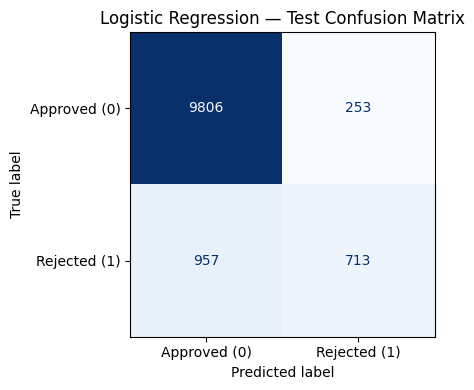

In [11]:
# confusion matrix for Logistic Regression
fig, ax = plt.subplots(figsize=(5, 4))
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Logistic Regression — Test Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_lr.png', dpi=150)
plt.show()

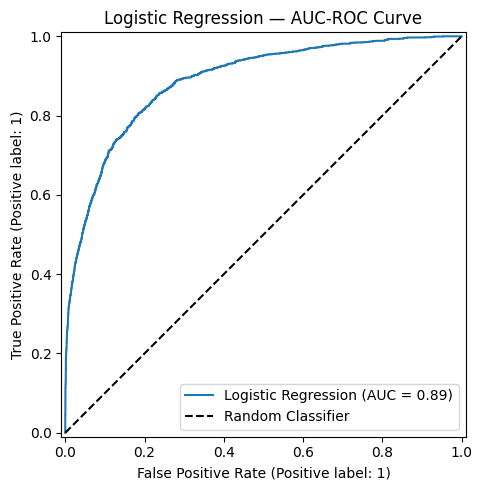

In [12]:
# AUC-ROC curve for Logistic Regression
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_lr, ax=ax,
                                  name='Logistic Regression')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('Logistic Regression — AUC-ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_lr.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Build and evaluate the K-Nearest Neighbours classifier

In [13]:
# create the KNN model with K=5 neighbours
# K=5 is a common starting point — odd number avoids ties in binary classification
# KNN uses scaled features because it is purely distance-based
# a feature with a large range would dominate the distance calculation without scaling
knn_model = KNeighborsClassifier(n_neighbors=5)

# train on scaled training data
knn_model.fit(X_train_sc, y_train)

# generate predictions on the scaled test data
y_pred_knn = knn_model.predict(X_test_sc)

# probability scores for AUC-ROC
y_prob_knn = knn_model.predict_proba(X_test_sc)[:, 1]

print('KNN (K=5) model trained and predictions generated')

KNN (K=5) model trained and predictions generated


In [14]:
# print the full classification report
print('=== KNN (K=5) — Classification Report ===')
print(classification_report(y_test, y_pred_knn, target_names=['Approved (0)', 'Rejected (1)']))

# calculate all five metrics
knn_accuracy  = accuracy_score(y_test, y_pred_knn)
knn_recall    = recall_score(y_test, y_pred_knn)
knn_precision = precision_score(y_test, y_pred_knn)
knn_f1        = f1_score(y_test, y_pred_knn)
knn_auc       = roc_auc_score(y_test, y_prob_knn)

print(f'Accuracy:  {knn_accuracy:.4f}')
print(f'Recall:    {knn_recall:.4f}')
print(f'Precision: {knn_precision:.4f}')
print(f'F1-Score:  {knn_f1:.4f}')
print(f'AUC-ROC:   {knn_auc:.4f}')

=== KNN (K=5) — Classification Report ===
              precision    recall  f1-score   support

Approved (0)       0.93      0.98      0.95     10059
Rejected (1)       0.82      0.55      0.65      1670

    accuracy                           0.92     11729
   macro avg       0.87      0.76      0.80     11729
weighted avg       0.91      0.92      0.91     11729

Accuracy:  0.9177
Recall:    0.5461
Precision: 0.8150
F1-Score:  0.6540
AUC-ROC:   0.8633


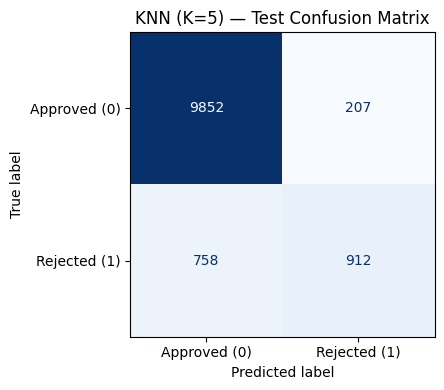

In [15]:
# confusion matrix for KNN
fig, ax = plt.subplots(figsize=(5, 4))
cm_knn = confusion_matrix(y_test, y_pred_knn)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn,
                               display_labels=['Approved (0)', 'Rejected (1)'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('KNN (K=5) — Test Confusion Matrix')
plt.tight_layout()
plt.savefig('cm_knn.png', dpi=150)
plt.show()

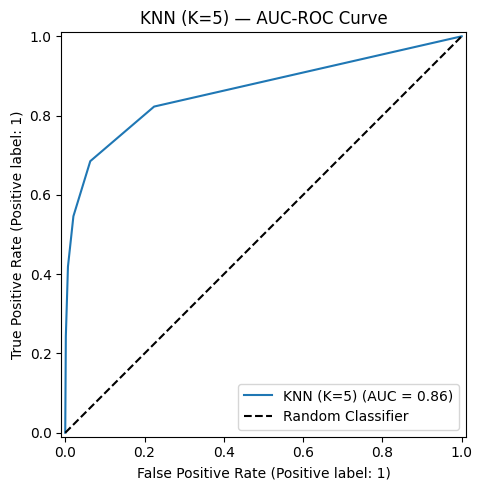

In [16]:
# AUC-ROC curve for KNN
fig, ax = plt.subplots(figsize=(6, 5))
RocCurveDisplay.from_predictions(y_test, y_prob_knn, ax=ax,
                                  name='KNN (K=5)')
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_title('KNN (K=5) — AUC-ROC Curve')
ax.legend()
plt.tight_layout()
plt.savefig('roc_knn.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Summarise and compare all three models using a results table

In [17]:
# build a summary table of all five metrics for all three models
# this makes it easy to compare performance at a glance for the report
results = pd.DataFrame({
    'Model':     ['Naive Bayes', 'Logistic Regression', 'KNN (K=5)'],
    'Accuracy':  [round(nb_accuracy,4),  round(lr_accuracy,4),  round(knn_accuracy,4)],
    'Recall':    [round(nb_recall,4),    round(lr_recall,4),    round(knn_recall,4)],
    'Precision': [round(nb_precision,4), round(lr_precision,4), round(knn_precision,4)],
    'F1-Score':  [round(nb_f1,4),        round(lr_f1,4),        round(knn_f1,4)],
    'AUC-ROC':   [round(nb_auc,4),       round(lr_auc,4),       round(knn_auc,4)]
})

# print the table
print(results.to_string(index=False))

# identify the best model by F1-Score — best balance of Precision and Recall
# CHANGED FROM: results.loc[results['AUC-ROC'].idxmax(), 'Model']
best_model_name = results.loc[results['F1-Score'].idxmax(), 'Model']
best_f1 = results['F1-Score'].max()
print(f'\n✅ Best model by F1-Score: {best_model_name} (F1 = {best_f1})')
print(f'   Reasoning: F1-Score balances Precision and Recall for the Rejected class,')
print(f'   which aligns with the business goal of catching risky loans accurately.')

              Model  Accuracy  Recall  Precision  F1-Score  AUC-ROC
        Naive Bayes    0.8851  0.3174     0.7182    0.4402   0.8448
Logistic Regression    0.8968  0.4269     0.7381    0.5410   0.8885
          KNN (K=5)    0.9177  0.5461     0.8150    0.6540   0.8633

✅ Best model by F1-Score: KNN (K=5) (F1 = 0.654)
   Reasoning: F1-Score balances Precision and Recall for the Rejected class,
   which aligns with the business goal of catching risky loans accurately.


**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Tune the best model (KNN) using GridSearchCV to optimise hyperparameters

In [18]:
# define the hyperparameter grid to search over
# n_neighbors (K) controls how many nearby points influence the prediction
# metric determines how distance between points is calculated
param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],      # Test different K values
    'metric':      ['euclidean', 'manhattan']   # Test two distance metrics
}

# create the GridSearchCV object
# StratifiedKFold(n_splits=5) means 5-fold stratified cross-validation
# each fold keeps the Approved/Rejected class balance similar to the full training set
# scoring='f1' — we optimise for F1-Score, consistent with our chosen best metric
grid_search = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=StratifiedKFold(n_splits=5),
    scoring='f1',
    n_jobs=-1
)

# fit GridSearchCV on the scaled training data — it tries all combinations
grid_search.fit(X_train_sc, y_train)

# print the winning hyperparameter combination
print('Best hyperparameters found by GridSearchCV:')
print(grid_search.best_params_)
print(f'Best cross-validated F1-Score: {grid_search.best_score_:.4f}')

Best hyperparameters found by GridSearchCV:
{'metric': 'manhattan', 'n_neighbors': 7}
Best cross-validated F1-Score: 0.6511


In [19]:
# retrieve the best estimator (already fitted with optimal hyperparameters)
best_knn = grid_search.best_estimator_

# generate predictions using the tuned model on the same test set
y_pred_tuned = best_knn.predict(X_test_sc)
y_prob_tuned = best_knn.predict_proba(X_test_sc)[:, 1]

# calculate metrics for the tuned model
tuned_recall    = recall_score(y_test, y_pred_tuned)
tuned_precision = precision_score(y_test, y_pred_tuned)
tuned_f1        = f1_score(y_test, y_pred_tuned)
tuned_auc       = roc_auc_score(y_test, y_prob_tuned)
tuned_accuracy  = accuracy_score(y_test, y_pred_tuned)

# compare before and after tuning side by side
print('--- Performance Before vs After Hyperparameter Tuning ---')
print(f'{"Metric":<12} {"Before":>10} {"After":>10} {"Change":>10}')
print('-' * 45)
print(f'{"Accuracy":<12} {knn_accuracy:>10.4f} {tuned_accuracy:>10.4f} {tuned_accuracy-knn_accuracy:>+10.4f}')
print(f'{"Recall":<12} {knn_recall:>10.4f} {tuned_recall:>10.4f} {tuned_recall-knn_recall:>+10.4f}')
print(f'{"Precision":<12} {knn_precision:>10.4f} {tuned_precision:>10.4f} {tuned_precision-knn_precision:>+10.4f}')
print(f'{"F1-Score":<12} {knn_f1:>10.4f} {tuned_f1:>10.4f} {tuned_f1-knn_f1:>+10.4f}')
print(f'{"AUC-ROC":<12} {knn_auc:>10.4f} {tuned_auc:>10.4f} {tuned_auc-knn_auc:>+10.4f}')

--- Performance Before vs After Hyperparameter Tuning ---
Metric           Before      After     Change
---------------------------------------------
Accuracy         0.9177     0.9221    +0.0043
Recall           0.5461     0.5425    -0.0036
Precision        0.8150     0.8580    +0.0429
F1-Score         0.6540     0.6647    +0.0107
AUC-ROC          0.8633     0.8756    +0.0123


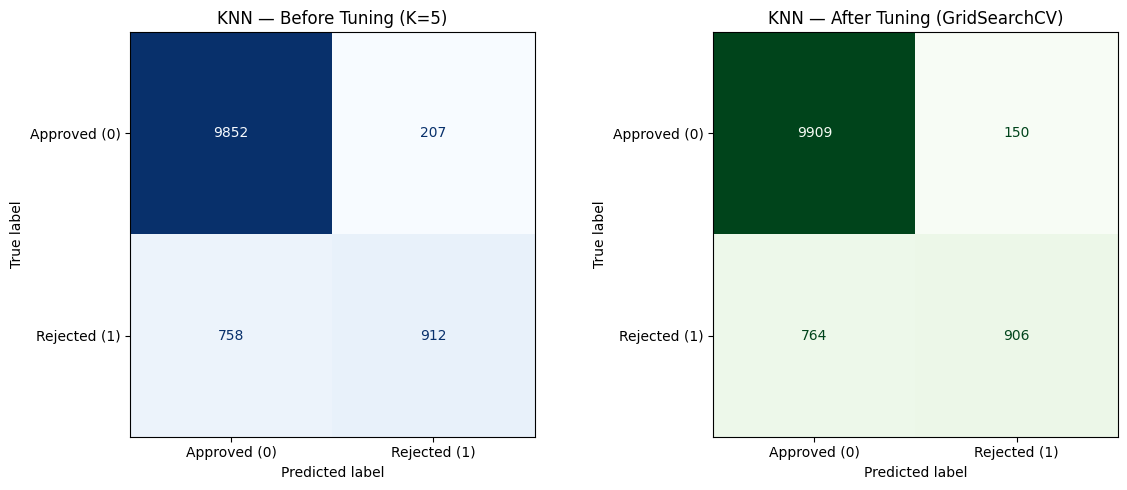

In [20]:
# confusion matrix BEFORE and AFTER tuning for KNN
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# before
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_knn),
                        display_labels=['Approved (0)', 'Rejected (1)']
                       ).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('KNN — Before Tuning (K=5)')

# after
ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_tuned),
                        display_labels=['Approved (0)', 'Rejected (1)']
                       ).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('KNN — After Tuning (GridSearchCV)')

plt.tight_layout()
plt.savefig('cm_knn_before_after.png', dpi=150)
plt.show()

**Code Source Citation**

* **Session:** Code Reuse Session 2 — Seminar Sessions
* **Purpose:** Plot all three model AUC-ROC curves on one chart for easy comparison

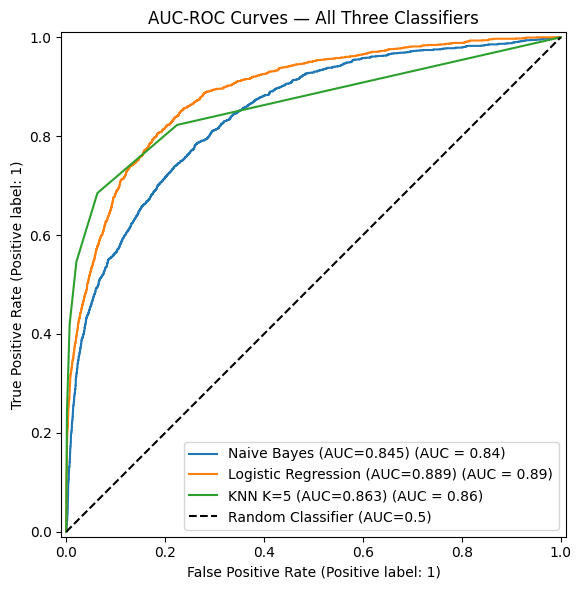

In [21]:
# overlay all three ROC curves on one figure so the report screenshot shows everything
fig, ax = plt.subplots(figsize=(7, 6))

# plot each model's ROC curve with its AUC value in the legend
RocCurveDisplay.from_predictions(y_test, y_prob_nb,  ax=ax, name=f'Naive Bayes (AUC={nb_auc:.3f})')
RocCurveDisplay.from_predictions(y_test, y_prob_lr,  ax=ax, name=f'Logistic Regression (AUC={lr_auc:.3f})')
RocCurveDisplay.from_predictions(y_test, y_prob_knn, ax=ax, name=f'KNN K=5 (AUC={knn_auc:.3f})')

# dashed diagonal represents a random classifier with AUC=0.5
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC=0.5)')

ax.set_title('AUC-ROC Curves — All Three Classifiers')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig('roc_all_models.png', dpi=150)
plt.show()